In [1]:
import os
import sys
path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_zero_shot.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_examples_entailment.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_examples_not_entailment.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_2_examples.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_qnli_Mistral_7B

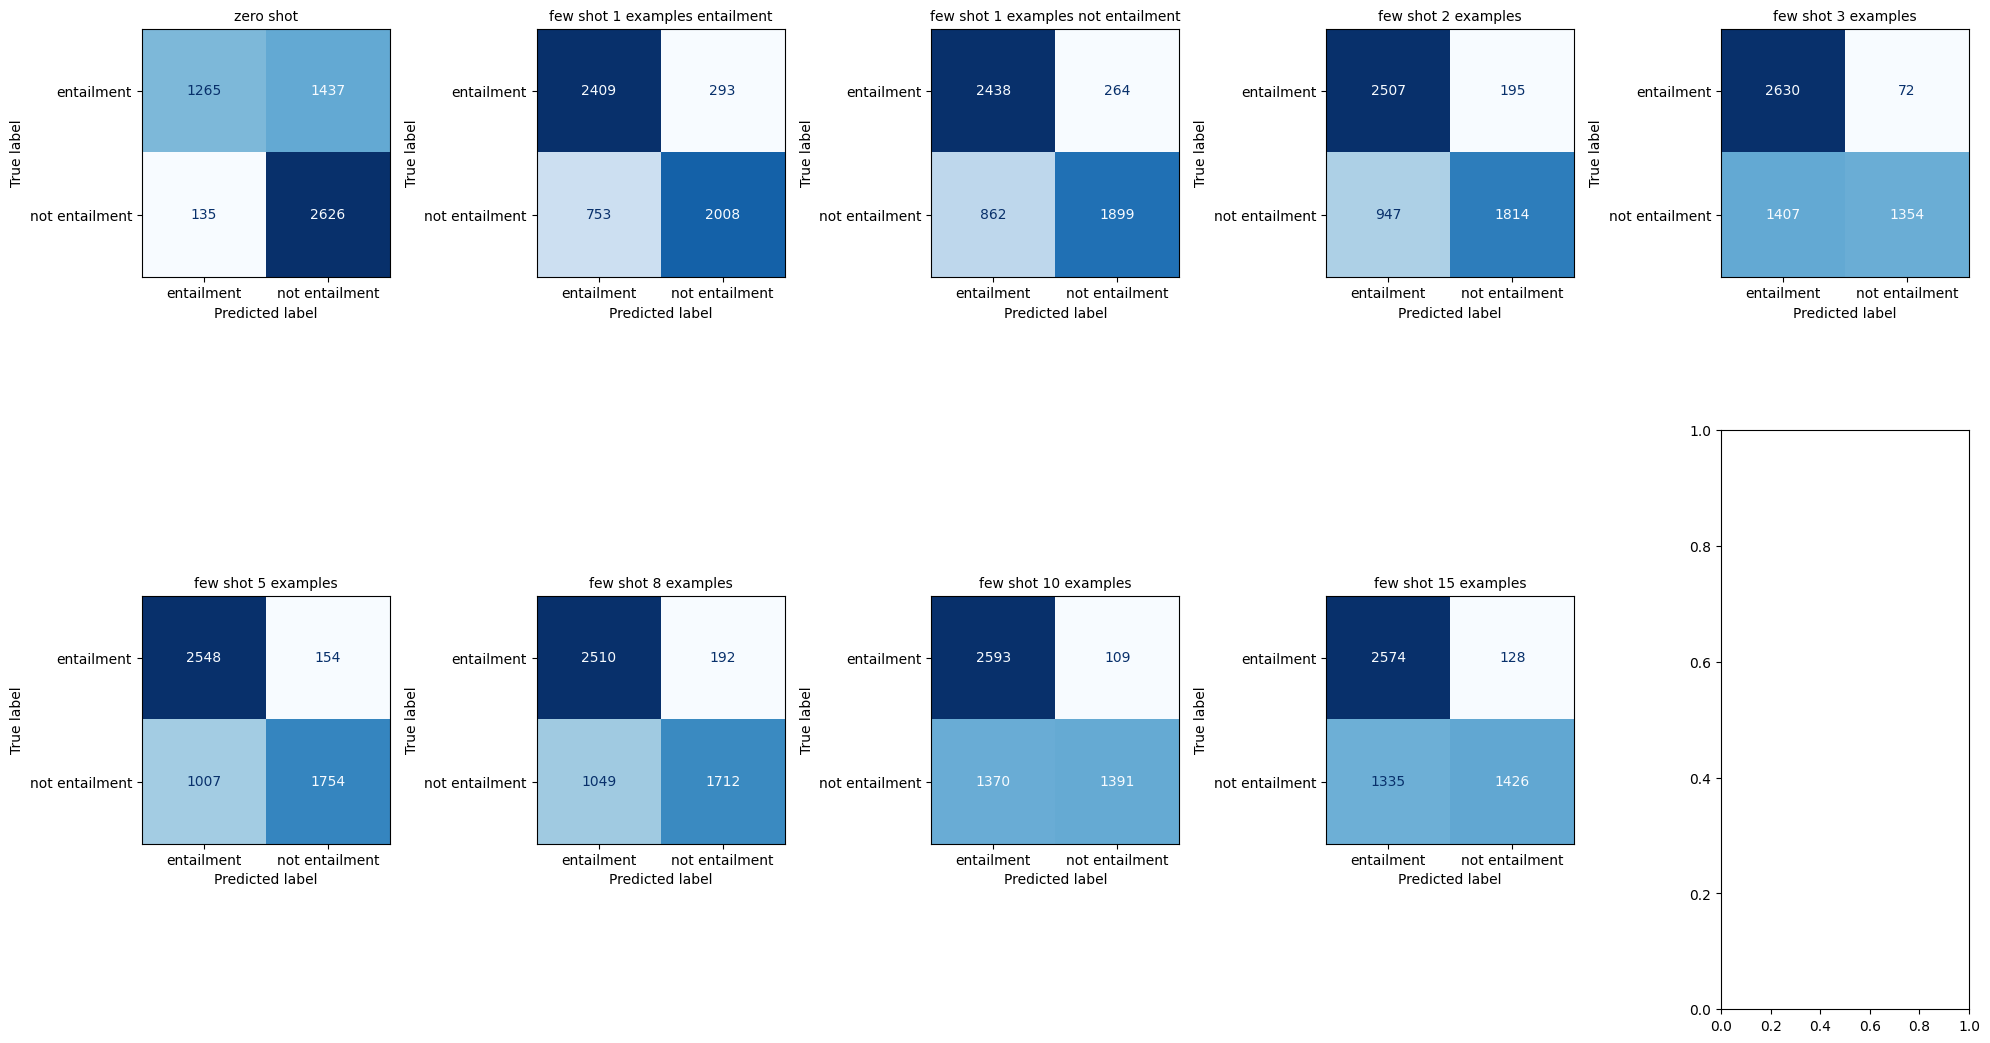

In [2]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot',
    'few shot 1 examples entailment',
    'few shot 1 examples not entailment',
    'few shot 2 examples',
    'few shot 3 examples',
    'few shot 5 examples',
    'few shot 8 examples',
    'few shot 10 examples',
    'few shot 15 examples'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {'dataset_type': 'qnli',
                'quantization': '4bit',
                'training_mode': mode,
                'model_id': 'mistralai/Mistral-7B-Instruct-v0.3'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
labels = [
    "0 examples",
    "1 example (entailment)",
    "1 example (not entailment)",
    "2 examples",
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.7122,0.7749,0.7096,0.6932,0.4802,0.4214
1 example (entailment),0.8085,0.8173,0.8094,0.8075,0.6266,0.6177
1 example (not entailment),0.7939,0.8084,0.7950,0.7919,0.6033,0.5887
2 examples,0.7910,0.8144,0.7924,0.7875,0.6064,0.5831
3 examples,0.7293,0.8005,0.7319,0.7136,0.5279,0.4613
5 examples,0.7875,0.8180,0.7891,0.7829,0.6065,0.5763
8 examples,0.7728,0.8022,0.7745,0.7679,0.5760,0.5472
10 examples,0.7293,0.7908,0.7317,0.7155,0.5192,0.4612
15 examples,0.7322,0.7881,0.7346,0.7198,0.5199,0.4669


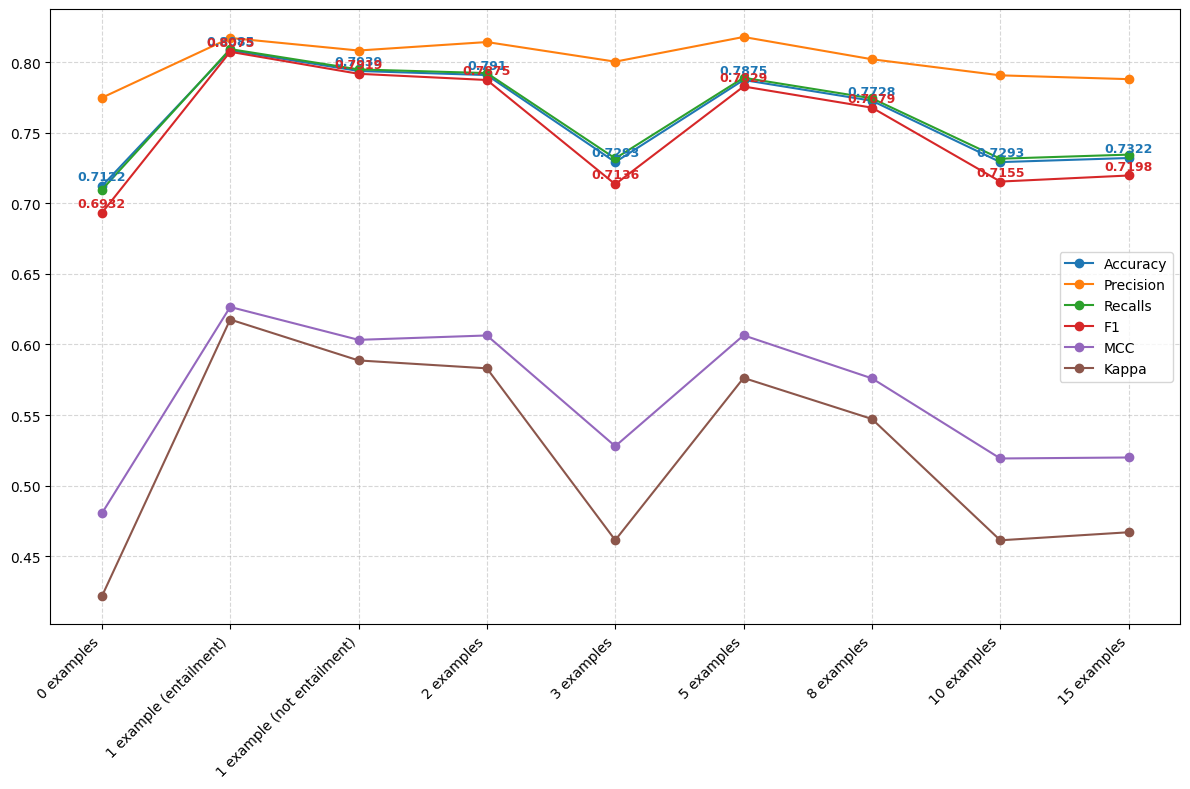

In [4]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_zero_shot_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_examples_entailment_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_examples_not_entailment_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mistral_7B_Instruct_v0_3/Results/checkpoint_qnli_Mistral_7B_Instruct_v0.3_4bit_few_shot_2_examples_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Mis

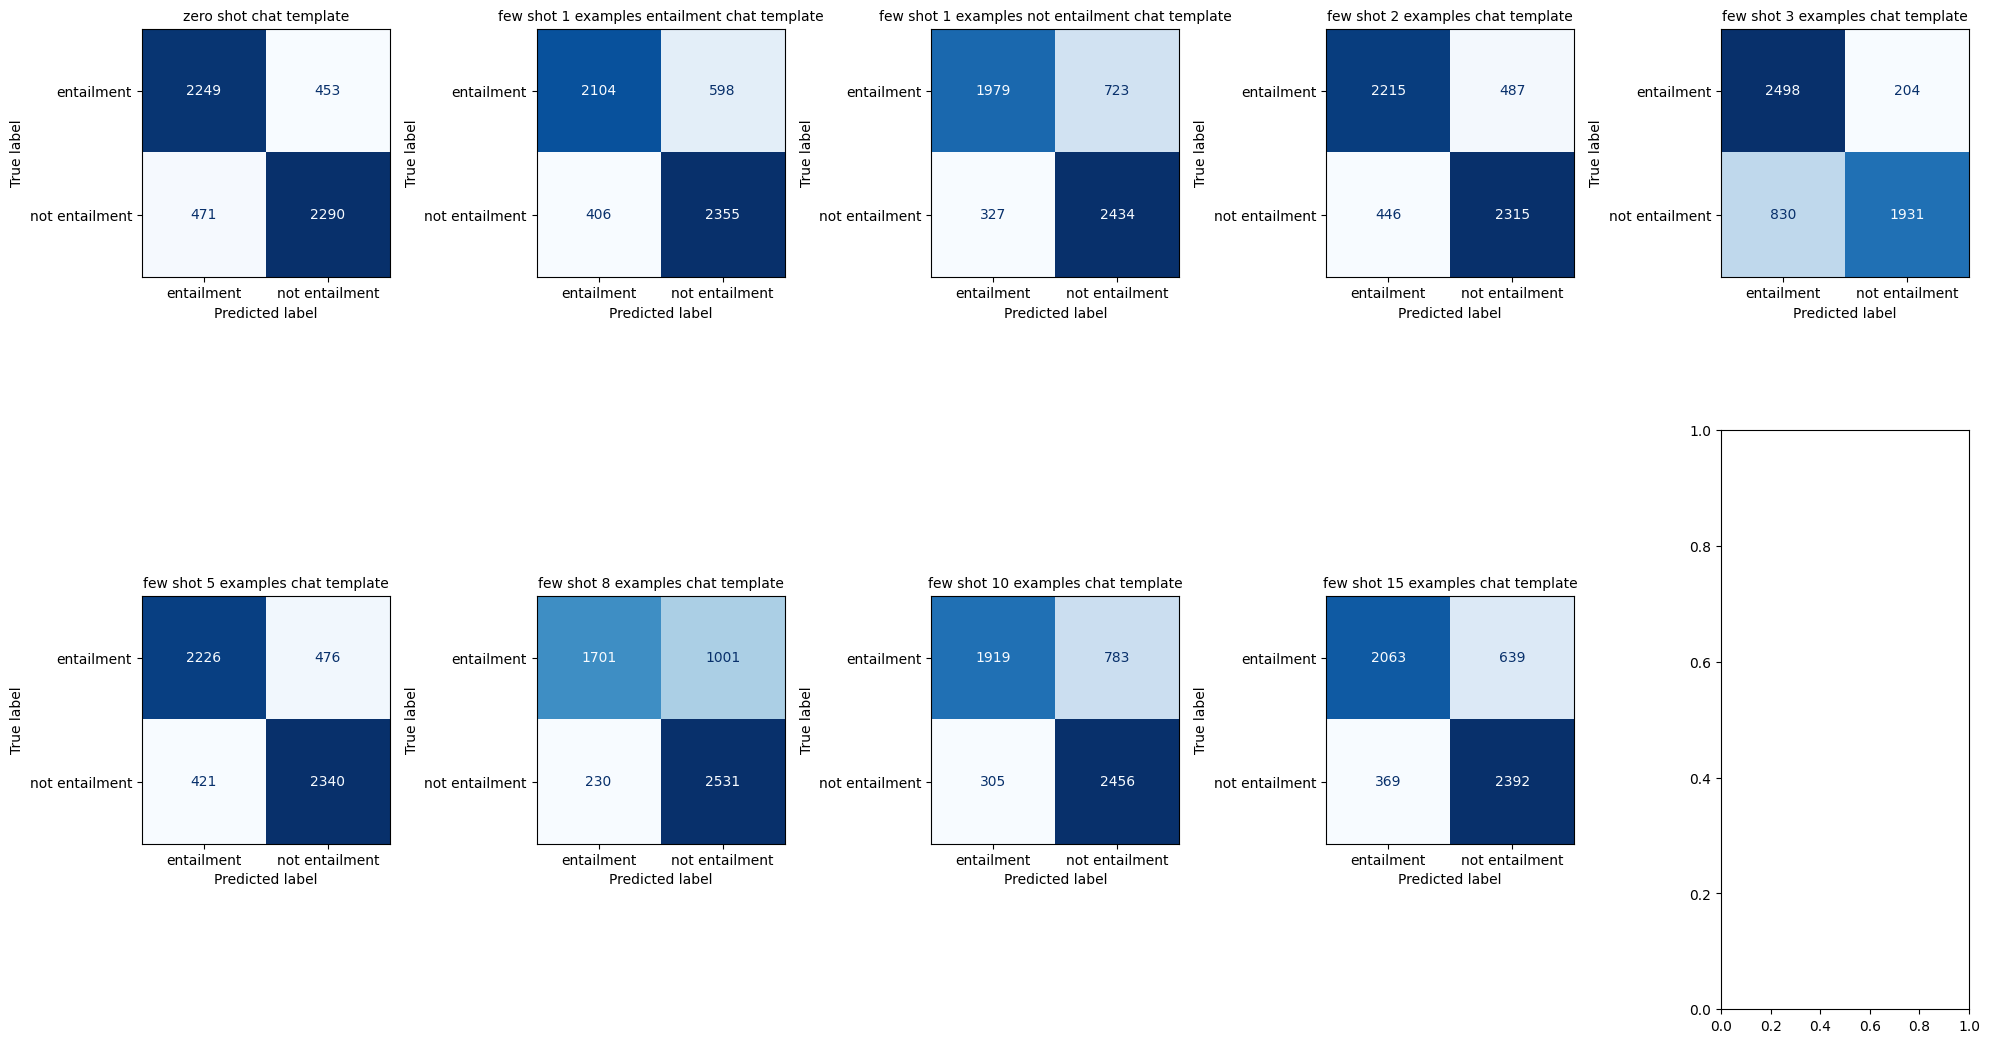

In [2]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot chat template',
    'few shot 1 examples entailment chat template',
    'few shot 1 examples not entailment chat template',
    'few shot 2 examples chat template',
    'few shot 3 examples chat template',
    'few shot 5 examples chat template',
    'few shot 8 examples chat template',
    'few shot 10 examples chat template',
    'few shot 15 examples chat template'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {'dataset_type': 'qnli',
                'quantization': '4bit',
                'training_mode': mode,
                'model_id': 'mistralai/Mistral-7B-Instruct-v0.3'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
labels = [
    "0 examples",
    "1 example (entailment)",
    "1 example (not entailment)",
    "2 examples",
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df_chat_template = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df_chat_template

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.8309,0.8308,0.8309,0.8309,0.6617,0.6617
1 example (entailment),0.8162,0.8179,0.8158,0.8158,0.6337,0.6321
1 example (not entailment),0.8078,0.8146,0.8070,0.8065,0.6215,0.6149
2 examples,0.8292,0.8293,0.8291,0.8292,0.6584,0.6583
3 examples,0.8107,0.8275,0.8119,0.8087,0.6393,0.6223
5 examples,0.8358,0.8360,0.8357,0.8357,0.6716,0.6715
8 examples,0.7747,0.7987,0.7731,0.7693,0.5713,0.5479
10 examples,0.8008,0.8106,0.7999,0.7989,0.6103,0.6009
15 examples,0.8155,0.8187,0.8149,0.8148,0.6336,0.6305


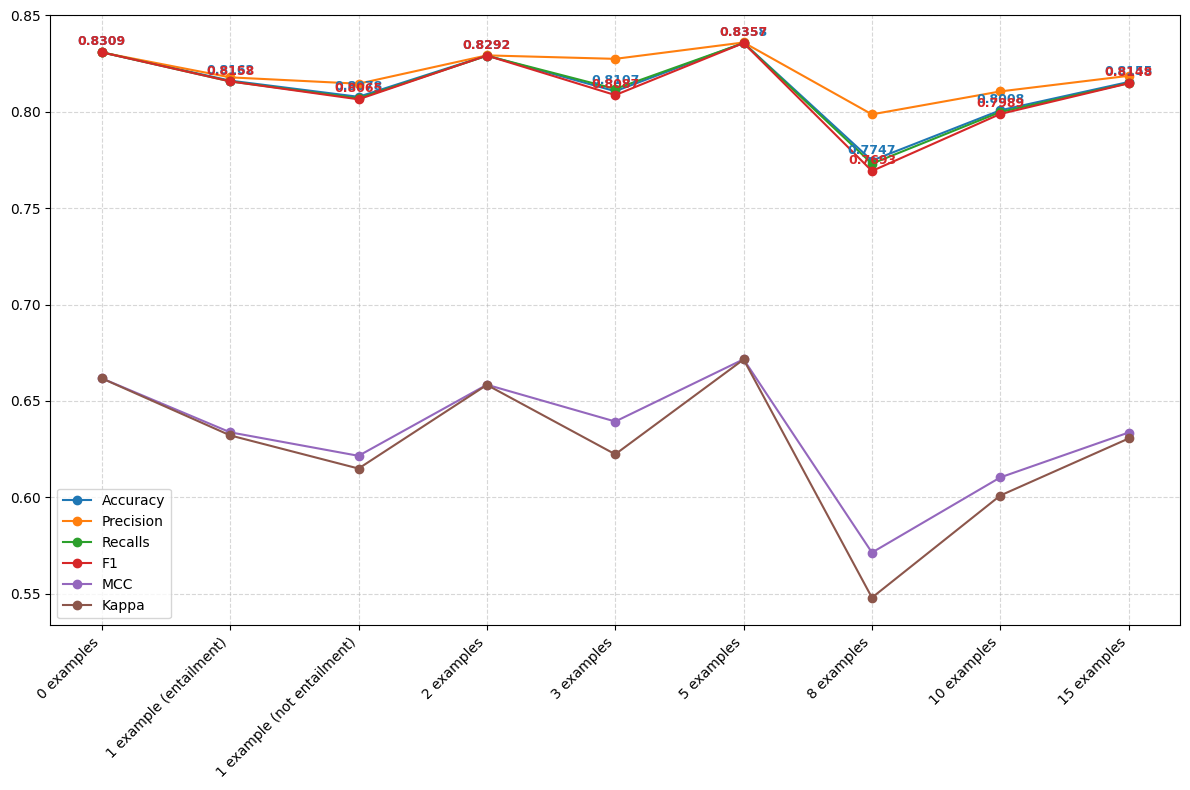

In [4]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df_chat_template.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df_chat_template.index)))
ax.set_xticklabels(metrics_df_chat_template.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df_chat_template[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df_chat_template.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()